In [1]:
# # Use Python 3.10 and this transformers==4.40.1 for stable compatibility
# ! pip install transformers==4.40.1

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM
import argparse

import sys                                                                                     
sys.path.append('..')  
from models import timer_xl

/home/aicode/miniconda3/envs/tsfm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# load model and dataset
# init the args of pre-trained Timer-XL

args = argparse.Namespace()
args.input_token_len = 96
args.output_token_len = 96
args.d_model = 1024
args.n_heads = 8
args.e_layers = 8
args.d_ff = 2048
args.dropout = 0.1
args.activation = 'relu'
args.use_norm = True
args.flash_attention = False
args.covariate = False
args.output_attention = False

model = timer_xl.Model(args)

# download the checkpoint from https://cloud.tsinghua.edu.cn/f/01c35ca13f474176be7b/
model.load_state_dict(torch.load('../checkpoint.pth')) 

<All keys matched successfully>

In [4]:
df = pd.read_csv("ETTh2.csv")

In [5]:
lookback_length = 1440      # support the maximum context length up to 2880 
input = torch.tensor(df.iloc[:,-1][:lookback_length]).unsqueeze(0).float()

# generate forecast 
prediction_length = 96     # forecast the next 96 timestamps, supporting maximum prediction length encompassed in the context length

output =  model(input.unsqueeze(-1), None, None)

In [6]:
print(output.shape)

torch.Size([1, 1440, 1])


In [7]:
pred = output[:, -prediction_length:, 0].squeeze().detach().numpy()

In [8]:
# # plot the prediction

# plt.figure(figsize=(12, 4))
# plt.plot(df["OT"][:lookback_length + prediction_length], color="limegreen", label="Groundtruth")
# plt.plot(range(lookback_length, lookback_length + prediction_length), pred, color="tomato", label="Prediction")
# plt.plot(df["OT"][:lookback_length], color="royalblue", label="Lookback")
# plt.legend()
# plt.grid()
# plt.show()

In [9]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 7.5, "font.weight": "normal",
    "axes.labelsize": 7.5, "axes.labelweight": "normal",
    "axes.titlesize": 7.5, "axes.titleweight": "bold", "axes.linewidth": 0.8,
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.minor.width": 0.5, "ytick.minor.width": 0.5,
    "legend.fontsize": 7.5, "legend.frameon": False,
    "grid.linestyle": "--", "grid.linewidth": 0.5, "grid.alpha": 0.3,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})     

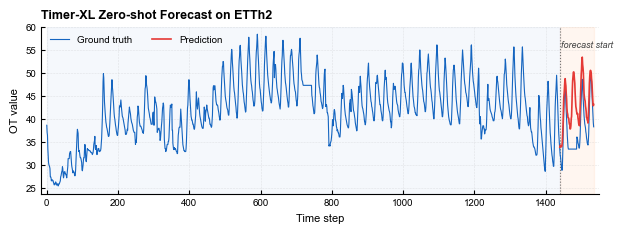

In [10]:
import matplotlib.pyplot as plt                         
import matplotlib.ticker as ticker
import numpy as np                                                                            

                                                                                   
                                                                                            
fig, ax = plt.subplots(figsize=(16/2.54, 6/2.54))                                            
                                                                                            
gt = df["OT"].values                                                                          
x_all = np.arange(lookback_length + prediction_length)                                      
x_pred = np.arange(lookback_length, lookback_length + prediction_length)                      
                                                                                            
# Lookback region shading                                                                   
ax.axvspan(0, lookback_length, alpha=0.04, color='#1565C0', zorder=0)                         
# Forecast region shading                                                                     
ax.axvspan(lookback_length, lookback_length + prediction_length, alpha=0.06, color='#FF6F00',
zorder=0)                                                                                     
                                                                                            
# Lines                                                                                       
ax.plot(x_all, gt[:lookback_length + prediction_length],                                     
        color='#1565C0', linewidth=0.8, label='Ground truth', zorder=3)                     
ax.plot(x_pred, pred,                                                                         
        color='#E53935', linewidth=1.2, label='Prediction', zorder=4)                         
                                                                                            
# Forecast boundary                                                                           
ax.axvline(lookback_length, color='#424242', linestyle=':', linewidth=0.8, alpha=0.7,       
zorder=2)                                                                                     
ax.text(lookback_length + 2, ax.get_ylim()[1] * 0.95, 'forecast start',                      
        fontsize=6.5, color='#424242', va='top', style='italic')                              
                                                                                            
ax.set_xlabel("Time step", fontsize=8)                                                        
ax.set_ylabel("OT value", fontsize=8)                                                         
ax.set_title("Timer-XL Zero-shot Forecast on ETTh2", loc='left', fontsize=9,                  
fontweight='bold', pad=6)                                                                     
                                                                                            
ax.spines['top'].set_visible(False)                                                           
ax.spines['right'].set_visible(False)                                                       
ax.tick_params(direction='in', length=3, width=0.8, labelsize=7)                             
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3)                                       
ax.margins(x=0.01)                                                                            
                                                                                            
ax.legend(loc='upper left', fontsize=7, frameon=False, ncol=2)                                
plt.tight_layout()                                                                          
plt.show()

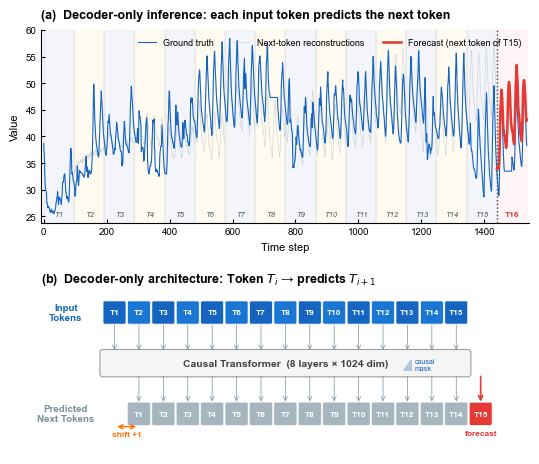

Saved decoder_only_architecture.png


In [11]:
import matplotlib.pyplot as plt                                                               
import matplotlib.patches as mpatches                                                         
import numpy as np                                                                          
                                                                                            
# ===== 提取所有 next-token prediction =====                                                  
output_all = output[0, :, 0].detach().numpy()   # (1440,) = 15 patches of predictions       
gt = df.iloc[:, -1].values                                                                    
P = prediction_length  # 96                                                                 
n_patches = lookback_length // P  # 15                                                        
                                                                                            
                                                                                            
fig = plt.figure(figsize=(16/2.54, 14/2.54))                                                  
gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 1], hspace=0.4)                              
                                                                                            
# ================================================================                          
# Panel (a): Time series with all 15 next-token predictions                                   
# ================================================================                            
ax = fig.add_subplot(gs[0])                                                                 
                                                                                            
# Alternating patch stripes                                                                 
for p in range(n_patches):                                                                    
    c = '#E8EAF6' if p % 2 == 0 else '#FFF8E1'                                               
    ax.axvspan(p*P, (p+1)*P, alpha=0.45, color=c, zorder=0)                                   
# Forecast zone                                                                               
ax.axvspan(n_patches*P, (n_patches+1)*P, alpha=0.18, color='#FFCDD2', zorder=0)               
                                                                                            
# Ground truth                                                                              
ax.plot(gt[:lookback_length + P], color='#1565C0', lw=0.8, label='Ground truth', zorder=4)    
                                                                                            
# 14 reconstruction predictions (gray)                                                        
for p in range(n_patches - 1):                                                                
    pred_p = output_all[p*P : (p+1)*P]                                                        
    target_start = (p+1) * P                                                                  
    lbl = 'Next-token reconstructions' if p == 0 else None                                   
    ax.plot(range(target_start, target_start + P), pred_p,                                    
            color='#B0BEC5', lw=0.5, alpha=0.55, label=lbl, zorder=2)                         
                                                                                            
# Last prediction = the actual forecast (red, bold)                                           
forecast_pred = output_all[(n_patches-1)*P : n_patches*P]                                     
ax.plot(range(lookback_length, lookback_length + P), forecast_pred,                           
        color='#E53935', lw=1.8, label='Forecast (next token of T15)', zorder=5)              
                                                                                            
# Patch boundary lines + labels at top                                                        
ylim = ax.get_ylim()                                                                          
y_label = ylim[0] + (ylim[1] - ylim[0]) * 0.06                                                
for p in range(n_patches):                                                                   
    ax.axvline(p*P, color='#9E9E9E', lw=0.3, alpha=0.5, zorder=1)                             
    ax.text(p*P + P/2, y_label, f'T{p+1}', ha='center', va='top',                             
            fontsize=5.5, color='#455A64', fontstyle='italic')                                
ax.axvline(lookback_length, color='#424242', ls=':', lw=1.0, zorder=3)                        
ax.text(lookback_length + P/2, y_label, f'T{n_patches+1}',                                    
        ha='center', va='top', fontsize=6, color='#E53935', fontweight='bold')                
                                                                                            
ax.set_ylabel('Value', fontsize=8)                                                            
ax.set_xlabel('Time step', fontsize=8)                                                       
ax.set_title('(a)  Decoder-only inference: each input token predicts the next token',         
            loc='left', fontsize=9, fontweight='bold', pad=8)                                
ax.legend(fontsize=6.5, frameon=False, loc='upper right', ncol=3)                            
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)                    
ax.tick_params(labelsize=7, direction='in', length=3)                                       
ax.margins(x=0.005)                                                                           
                                                                                            
# ================================================================                            
# Panel (b): Architecture schematic                                                           
# ================================================================                          
ax2 = fig.add_subplot(gs[1])                                                                 
ax2.set_xlim(-2.5, n_patches + 2.5)                                                          
ax2.set_ylim(-0.8, 4.2)                                                                       
ax2.axis('off')                                                                               
                                                                                            
bw, bh = 0.82, 0.6  # box width, height                                                       
                                                                                            
# --- Input tokens (top row) ---                                                              
for p in range(n_patches):                                                                   
    c = '#1565C0' if p % 2 == 0 else '#1976D2'                                                
    rect = mpatches.FancyBboxPatch((p + 0.09, 3.3), bw, bh,                                   
            boxstyle="round,pad=0.06", fc=c, ec='white', lw=0.5)                              
    ax2.add_patch(rect)                                                                       
    ax2.text(p + 0.5, 3.6, f'T{p+1}', ha='center', va='center',                               
            fontsize=6, color='white', fontweight='bold')                                    
                                                                                            
# --- Causal Transformer block (middle) ---                                                   
tf_rect = mpatches.FancyBboxPatch((0, 1.7), n_patches, 0.65,                                 
            boxstyle="round,pad=0.1", fc='#F5F5F5', ec='#9E9E9E', lw=0.8)                     
ax2.add_patch(tf_rect)                                                                        
ax2.text(n_patches/2, 2.02, 'Causal Transformer  (8 layers × 1024 dim)',                      
        ha='center', va='center', fontsize=7.5, fontweight='bold', color='#424242')          
                                                                                            
# Causal mask triangle (small)                                                                
tri_x, tri_y = n_patches * 0.82, 1.82                                                         
tri_size = 0.35                                                                               
triangle = plt.Polygon([                                                                     
    [tri_x, tri_y], [tri_x + tri_size, tri_y], [tri_x + tri_size, tri_y + tri_size]           
], closed=True, fc='#1565C0', alpha=0.3, ec='#1565C0', lw=0.5)                                
ax2.add_patch(triangle)                                                                       
ax2.text(tri_x + tri_size + 0.15, tri_y + tri_size/2, 'causal\nmask',                         
        fontsize=5, color='#1565C0', va='center')                                            
                                                                                            
# --- Output predictions (bottom row, shifted +1) ---                                         
for p in range(n_patches):                                                                    
    target = p + 1                                                                            
    is_forecast = (p == n_patches - 1)                                                       
    c = '#E53935' if is_forecast else '#78909C'                                               
    alpha = 1.0 if is_forecast else 0.65                                                     
    rect = mpatches.FancyBboxPatch((target + 0.09, 0.15), bw, bh,                             
            boxstyle="round,pad=0.06", fc=c, ec='white', lw=0.5, alpha=alpha)               
    ax2.add_patch(rect)                                                                       
    label = f'T{target}' if not is_forecast else f'T{target}'                                
    ax2.text(target + 0.5, 0.45, label, ha='center', va='center',                             
            fontsize=6, color='white', fontweight='bold')                                   
    if is_forecast:                                                                           
        ax2.text(target + 0.5, -0.15, 'forecast', ha='center', va='center',                
                fontsize=6, color='#E53935', fontweight='bold')                              
                                                                                            
# --- Arrows: input → transformer → output ---                                                
for p in range(n_patches):                                                                   
    # input → transformer                                                                     
    ax2.annotate('', xy=(p+0.5, 2.35), xytext=(p+0.5, 3.3),                                  
                arrowprops=dict(arrowstyle='->', color='#78909C', lw=0.5))                   
    # transformer → output (shifted +1)                                                       
    ax2.annotate('', xy=(p+1+0.5, 0.75), xytext=(p+1+0.5, 1.7),                               
                arrowprops=dict(arrowstyle='->', color='#78909C', lw=0.5))                   
                                                                                            
# Highlight the forecast arrow                                                                
ax2.annotate('', xy=(n_patches+0.5, 0.75), xytext=(n_patches+0.5, 1.7),                       
            arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.2))                       
                                                                                            
# --- Row labels ---                                                                          
ax2.text(-1.5, 3.6, 'Input\nTokens', ha='center', va='center',                              
        fontsize=7, fontweight='bold', color='#1565C0')                                      
ax2.text(-1.5, 0.45, 'Predicted\nNext Tokens', ha='center', va='center',                     
        fontsize=7, fontweight='bold', color='#78909C')                                      
                                                                                            
# --- "shift-by-1" annotation ---                                                             
ax2.annotate('', xy=(1.5, 0.05), xytext=(0.5, 0.05),                                         
            arrowprops=dict(arrowstyle='<->', color='#FF6F00', lw=1.0))                      
ax2.text(1.0, -0.25, 'shift +1', ha='center', fontsize=6, color='#FF6F00', fontweight='bold')
                                                                                            
ax2.set_title('(b)  Decoder-only architecture: Token $T_i$ → predicts $T_{i+1}$',             
            loc='left', fontsize=9, fontweight='bold', pad=8)                               
                                                                                            
plt.savefig("decoder_only_architecture.png", dpi=600, bbox_inches='tight', facecolor='white') 
plt.show()                                                                                   
print("Saved decoder_only_architecture.png")                                                  